# import libraries

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering
import numpy as np
from sklearn.metrics import confusion_matrix, pairwise_distances_argmin, accuracy_score
from scipy.optimize import linear_sum_assignment
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Read dataset

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

# Feature names and target names
feature_names = iris.feature_names
target_names = iris.target_names

print("Feature names:", feature_names)
print("Target names:", target_names)
print("First 5 samples:\n", X[:5])
print("First 5 labels:", y[:5])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)
print("y_train.shape:", y_train.shape)
print("y_test.shape:", y_test.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
First 5 samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 labels: [0 0 0 0 0]
X_train.shape: (105, 4)
X_test.shape: (45, 4)
y_train.shape: (105,)
y_test.shape: (45,)


# Define utilities

In [4]:
def get_label_mapping(y_true, cluster_labels):
    """
    Compute optimal mapping between cluster IDs and true labels
    using Hungarian algorithm.
    """
    cm = confusion_matrix(y_true, cluster_labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    return {col: row for row, col in zip(row_ind, col_ind)}


def apply_mapping(labels, mapping):
    """Safely map cluster labels to class labels."""
    return np.array([mapping.get(lbl, -1) for lbl in labels])


def clustering_accuracy(y_true, cluster_labels):
    """Clustering accuracy after optimal label alignment."""
    mapping = get_label_mapping(y_true, cluster_labels)
    mapped_labels = apply_mapping(cluster_labels, mapping)
    return np.mean(mapped_labels == y_true), mapping



# Train Kmeans clustering

In [5]:
# KMeans with k-means++ initialization
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",   # this is the kmeans++ algorithm
    n_init=10,
    random_state=42
)

# Train
kmeans.fit(X_train)

# Results
kmeans_labels = kmeans.labels_
kmeans_centers = kmeans.cluster_centers_

print("Cluster labels (first 10):", kmeans_labels[:10])
print("Cluster centers:\n", kmeans_centers)

Cluster labels (first 10): [2 2 0 1 2 1 0 0 0 1]
Cluster centers:
 [[4.98857143 3.42571429 1.48571429 0.24      ]
 [6.97692308 3.14230769 5.84615385 2.11153846]
 [5.925      2.70909091 4.39545455 1.43863636]]


# calculate accuracy

In [8]:
# def clustering_accuracy(y_true, y_pred):
#     cm = confusion_matrix(y_true, y_pred)
#     row_ind, col_ind = linear_sum_assignment(-cm)
#     return cm[row_ind, col_ind].sum() / cm.sum()

kmeans_test_labels = kmeans.predict(X_test)
test_acc, mapping = clustering_accuracy(y_test, kmeans_test_labels)
print("KMeans accuracy:", test_acc)

KMeans accuracy: 0.8666666666666667


# Train hierarchical clustering and calculate its acc

In [10]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

train_clusters = hc.fit_predict(X_train)

train_acc, mapping = clustering_accuracy(y_train, train_clusters)
print("Hierarchical clustering train accuracy:", train_acc)

Hierarchical clustering train accuracy: 0.9047619047619048


In [12]:
# Compute centroids
centroids = np.vstack([
    X_train[train_clusters == k].mean(axis=0)
    for k in np.unique(train_clusters)
])

# Assign test clusters
test_clusters = pairwise_distances_argmin(X_test, centroids)

# Apply same mapping
y_train_mapped = apply_mapping(train_clusters, mapping)
y_test_mapped  = apply_mapping(test_clusters, mapping)

test_acc = np.mean(y_test_mapped == y_test)
print("Hierarchical clustering test accuracy:", test_acc)

Hierarchical clustering test accuracy: 0.8888888888888888


# Train mlp classifier

In [20]:
# Create pipeline (scaling is VERY important for MLP)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        # early_stopping=False, 
        # tol=0, 
        random_state=42))
])

# Define parameter distributions
param_dist = {
    'mlp__hidden_layer_sizes': [
        (50,), (100,),
        (10, 10), 
        (50, 50), (100, 50),
        (10, 10),
        (100, 100), 
        (200, 100),
        (200, 200),
        (100, 100, 100),
        (200, 100, 50),
        (50, 50, 50),
    ],
    'mlp__max_iter': randint(300, 1000),
    'mlp__alpha': uniform(1e-4, 1e-2),
    'mlp__learning_rate_init': uniform(1e-4, 1e-2)
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Train using cluster-generated labels
random_search.fit(X_train, y_train_mapped)

print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# Evaluate
mlp_test_score = random_search.score(X_test, y_test)
print("MLP Test accuracy (on clustered labels):", mlp_test_score)

Best parameters: {'mlp__alpha': np.float64(0.003763618432936917), 'mlp__hidden_layer_sizes': (10, 10), 'mlp__learning_rate_init': np.float64(0.003924619912671627), 'mlp__max_iter': 543}
Best CV score: 1.0
MLP Test accuracy (on clustered labels): 0.8666666666666667


In [21]:
lr = random_search.best_params_['mlp__learning_rate_init']
hidden_layer_sizes = random_search.best_params_['mlp__hidden_layer_sizes']
alpha = random_search.best_params_['mlp__alpha']

In [22]:
# Store results for analysis
results = []



for epoch in np.arange(100, 5000, 100):
    # Create pipeline with explicit naming
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            learning_rate_init=lr,
            max_iter=epoch,
            alpha=alpha,
            random_state=42,
            early_stopping=False,
            tol=0,
            verbose=False  # Suppress convergence warnings if any
        ))
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train_mapped)
    
    # Make predictions
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    train_score = pipeline.score(X_train, y_train_mapped)
    test_score = pipeline.score(X_test, y_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results.append({
        'epoch': epoch,
        'train_accuracy': train_score,
        'test_accuracy': test_score,
        'accuracy_diff': train_score - test_score
    })
    
    # Print formatted output
    print(f"Epochs: {epoch:4d} | Train Acc: {train_score:.4f} | Test Acc: {test_score:.4f} | Diff: {train_score - test_score:.4f}")

# Optional: Display summary
print("\n" + "="*60)
print("Summary of Results:")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Find best epoch based on test accuracy
best_result = max(results, key=lambda x: x['test_accuracy'])
print(f"\nBest epoch: {best_result['epoch']} with test accuracy: {best_result['test_accuracy']:.4f}")

c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs:  100 | Train Acc: 0.9429 | Test Acc: 0.7556 | Diff: 0.1873
Epochs:  200 | Train Acc: 1.0000 | Test Acc: 0.8444 | Diff: 0.1556
Epochs:  300 | Train Acc: 1.0000 | Test Acc: 0.8667 | Diff: 0.1333


c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs:  400 | Train Acc: 1.0000 | Test Acc: 0.8667 | Diff: 0.1333
Epochs:  500 | Train Acc: 1.0000 | Test Acc: 0.8889 | Diff: 0.1111


c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(


...

c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (4700) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs: 4700 | Train Acc: 1.0000 | Test Acc: 0.8889 | Diff: 0.1111


c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (4800) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs: 4800 | Train Acc: 1.0000 | Test Acc: 0.8889 | Diff: 0.1111
Epochs: 4900 | Train Acc: 1.0000 | Test Acc: 0.8889 | Diff: 0.1111

Summary of Results:
 epoch  train_accuracy  test_accuracy  accuracy_diff
   100        0.942857       0.755556       0.187302
   200        1.000000       0.844444       0.155556
   300        1.000000       0.866667       0.133333
   400        1.000000       0.866667       0.133333
   500        1.000000       0.888889       0.111111
   600        1.000000       0.888889       0.111111
   700        1.000000       0.888889       0.111111
   800        1.000000       0.888889       0.111111
   900        1.000000       0.888889       0.111111
  1000        1.000000       0.888889       0.111111
  1100        1.000000       0.888889       0.111111
  1200        1.000000       0.888889       0.111111
  1300        1.000000       0.888889       0.111111
  1400        1.000000       0.888889       0.111111
  1500        1.000000       0.888889       0.1111

c:\Anaconda\envs\torch-gpu\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (4900) reached and the optimization hasn't converged yet.
  warnings.warn(




# 1️⃣ Core Idea

When you train an MLP on pseudo-labels, the MLP is **learning whatever signal exists inside those labels**.

So:

> **Better pseudo-labels → Better supervised signal → Higher MLP accuracy**

> **Noisy pseudo-labels → Corrupted supervision → Lower MLP accuracy**

---

# 2️⃣ Why This Happens (Mathematically)

Training an MLP minimizes:

$$
\mathcal{L}(f_\theta(X), \tilde{y})
$$

Where:

* $\tilde{y}$ = pseudo labels
* $y$ = true labels

If pseudo-labels are close to true labels:

$$
P(\tilde{y} = y) \text{ is high}
$$

Then the optimization is approximately learning the correct task.

If pseudo-labels are noisy:

$$
P(\tilde{y} \neq y) \text{ is high}
$$

Then the MLP is literally learning incorrect targets.

This is equivalent to **label noise in supervised learning**.

---

# 3️⃣ In Your Specific Pipeline

You are doing:

1. Hierarchical clustering
2. Align clusters with Hungarian algorithm
3. Train MLP on mapped cluster labels

So the relationship becomes:

$$
\textbf{MLP accuracy ≤ clustering accuracy}
$$

Why?

Because the MLP **cannot recover information that is not present in the pseudo-labels**.

If clustering accuracy = 75%
→ The maximum theoretical supervised signal is about 75%.

The MLP might:

* Slightly improve due to better decision boundaries
* Or slightly degrade due to overfitting noise

But it cannot magically reach 95% if clustering only captures 75% of structure.

---

# 4️⃣ When Pseudo-Labeling Helps

Pseudo-labeling improves MLP accuracy when:

✔ Clusters align well with real classes
✔ Data is naturally well separated
✔ You have few labeled samples
✔ You filter low-confidence assignments

It hurts when:

✖ Clusters mix multiple classes
✖ High intra-class variance
✖ Overlapping distributions
✖ You trust all cluster assignments blindly

---

# 5️⃣ Practical Rule of Thumb

If clustering accuracy is:

* **> 85%** → MLP will likely perform well
* **70–85%** → MLP may improve slightly
* **< 60%** → MLP likely learns noise

---

# 6️⃣ Important Insight

Pseudo-labeling works best when:

The model generating labels is already decent.

That’s why modern semi-supervised methods use:

* High-confidence filtering
* Teacher–student models
* Consistency regularization

Not raw clustering alone.

---

# 🎯 In Your Case

Check this:

```python
print("Clustering accuracy:", train_acc)
print("MLP CV accuracy:", random_search.best_score_)
```

If MLP accuracy is much lower than clustering accuracy →
MLP is struggling to fit noisy labels.

If it's similar →
Clustering defines the performance ceiling.


In [24]:
def plot_confusion_matrices(
    y_true,
    cluster_labels=None,
    mlp_model=None,
    X=None,
    title_suffix=""
):
    """
    Plots confusion matrices for clustering and MLP.
    
    Parameters
    ----------
    y_true : array-like
        True labels.
    cluster_labels : array-like, optional
        Cluster assignments (will be aligned automatically).
    mlp_model : trained sklearn classifier, optional
        Trained MLP (or any classifier).
    X : array-like, optional
        Features (required if mlp_model is given).
    title_suffix : str
        Extra string to add to plot titles.
    """

    n_plots = sum([cluster_labels is not None,
                   mlp_model is not None])

    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    plot_index = 0

    # =====================================================
    # 1️⃣ Clustering Confusion Matrix (Aligned)
    # =====================================================
    if cluster_labels is not None:
        cm = confusion_matrix(y_true, cluster_labels)

        # Hungarian alignment
        row_ind, col_ind = linear_sum_assignment(-cm)
        mapping = {col: row for row, col in zip(row_ind, col_ind)}
        aligned_clusters = np.array(
            [mapping.get(lbl, -1) for lbl in cluster_labels]
        )

        cm_aligned = confusion_matrix(y_true, aligned_clusters)

        disp = ConfusionMatrixDisplay(cm_aligned)
        disp.plot(ax=axes[plot_index], colorbar=False)
        axes[plot_index].set_title(f"Clustering Confusion Matrix {title_suffix}")
        plot_index += 1

    # =====================================================
    # 2️⃣ MLP Confusion Matrix
    # =====================================================
    if mlp_model is not None and X is not None:
        y_pred = mlp_model.predict(X)
        cm_mlp = confusion_matrix(y_true, y_pred)

        disp = ConfusionMatrixDisplay(cm_mlp)
        disp.plot(ax=axes[plot_index], colorbar=False)
        axes[plot_index].set_title(f"MLP Confusion Matrix {title_suffix}")

    plt.tight_layout()
    plt.show()



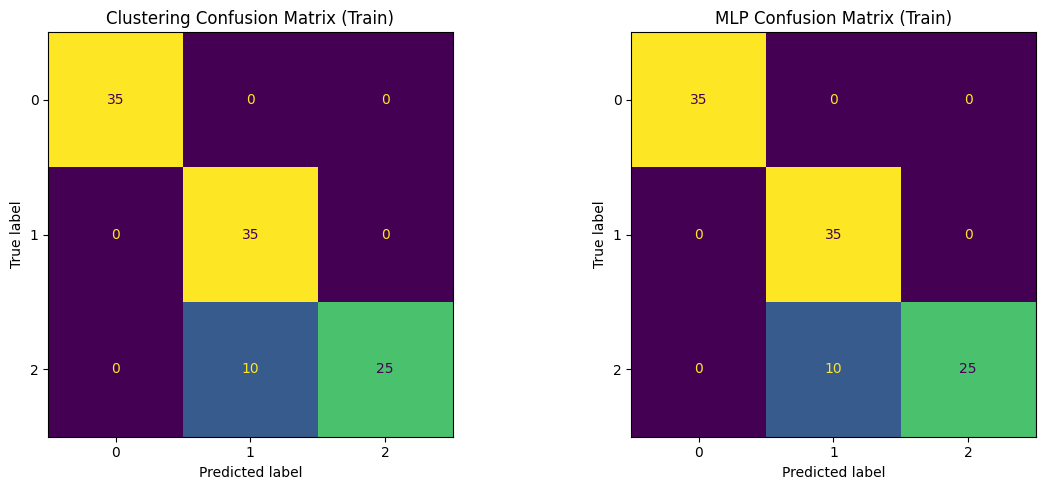

In [25]:
plot_confusion_matrices(
    y_true=y_train,
    cluster_labels=train_clusters,
    mlp_model=random_search.best_estimator_,
    X=X_train,
    title_suffix="(Train)"
)

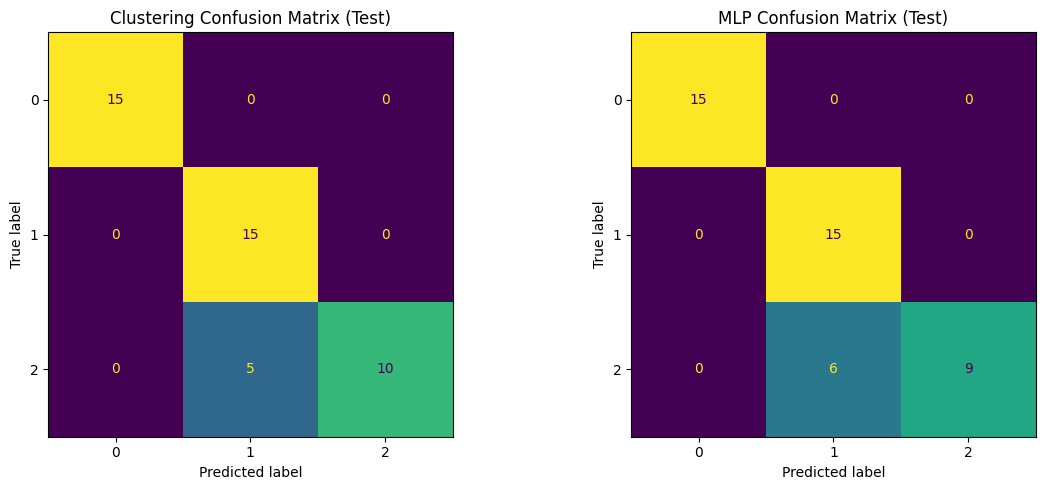

In [26]:
plot_confusion_matrices(
    y_true=y_test,
    cluster_labels=test_clusters,
    mlp_model=random_search.best_estimator_,
    X=X_test,
    title_suffix="(Test)"
)